Q1. (Creating Non-Linear Dataset)
Generate a synthetic dataset using make_moons with:
n_samples=500
noise=0.05
random_state=42
Convert it into a DataFrame with columns Feature1 and Feature2.
Display the first 10 rows and shape of the dataset.

In [48]:
import pandas as pd
from sklearn.datasets import make_moons

#Generate synthetic dataset
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)
#Convert into DataFrame
df_moons = pd.DataFrame(X, columns=["Feature1", "Feature2"])
#Display first 10 rows
print(df_moons.head(10))
#Display shape of dataset
print("Shape of dataset:", df_moons.shape)


   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959
Shape of dataset: (500, 2)


Q2. (Scaling the Data)
Apply Standard Scaling on the dataset created in Q1.
Use StandardScaler.
Store the scaled data in X_scaled.
Show the first 5 rows of the scaled data.

In [49]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the dataset from Q1
X_scaled = scaler.fit_transform(df_moons)

# Convert scaled data into DataFrame for easy viewing
df_scaled = pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"])

# Show first 5 rows
print(df_scaled.head())


   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


Q3. (K-Means on Non-Linear Data)
Apply KMeans clustering with n_clusters=2 on the scaled moon dataset.
Fit and predict the cluster labels.
Add the labels to the DataFrame as kmeans_cluster.
Create a scatter plot to visualize the KMeans clusters.

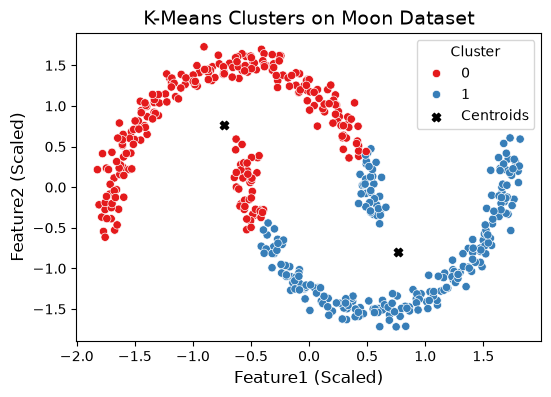

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
# Apply KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(df_scaled)
# Add cluster labels to DataFrame
df_scaled["kmeans_cluster"] = labels
# Scatter plot to visualize clusters
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Feature1", 
    y="Feature2", 
    hue="kmeans_cluster", 
    data=df_scaled, 
    palette="Set1", 
)
# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:,0], centroids[:,1], 
    c="black", marker="X", label="Centroids"
)
plt.title("K-Means Clusters on Moon Dataset", fontsize=14)
plt.xlabel("Feature1 (Scaled)", fontsize=12)
plt.ylabel("Feature2 (Scaled)", fontsize=12)
plt.legend(title="Cluster")
plt.show()

Q4. (DBSCAN Clustering)
Apply DBSCAN on the same scaled data with:
eps=0.3
min_samples=5
Predict the cluster labels.
Add the labels to the DataFrame as dbscan_cluster.
Create a scatter plot to visualize the DBSCAN clusters (including noise points
if any).

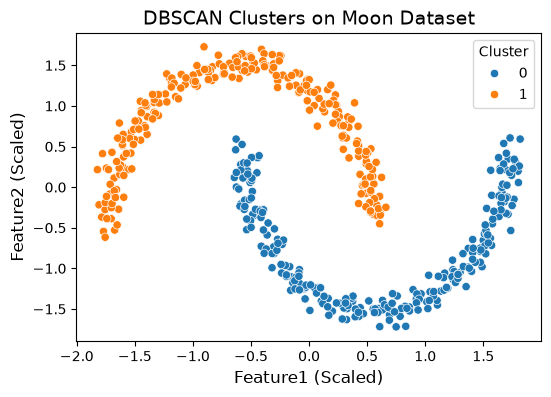

In [51]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(df_scaled[["Feature1", "Feature2"]])
# Add labels to DataFrame
df_scaled["dbscan_cluster"] = db_labels
# Scatter plot to visualize DBSCAN clusters
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Feature1", 
    y="Feature2", 
    hue="dbscan_cluster", 
    data=df_scaled, 
)
plt.title("DBSCAN Clusters on Moon Dataset", fontsize=14)
plt.xlabel("Feature1 (Scaled)", fontsize=12)
plt.ylabel("Feature2 (Scaled)", fontsize=12)
plt.legend(title="Cluster")
plt.show()


Q5. (Comparing KMeans vs DBSCAN)
Using the plots from Q3 and Q4:
Compare the clustering results of KMeans and DBSCAN visually.
Write observations about how DBSCAN handles non-spherical clusters and
noise better than KMeans.

In [52]:
##KMeans (Q3)
#Assumes clusters are spherical and evenly sized.
#It cuts across the moon shapes, splitting them incorrectly.
#Struggles with non-linear boundaries, so the two half-moons overlap in its clustering.
#No concept of noise — every point must belong to a cluster.

##DBSCAN (Q4)
#Groups points based on density, so it naturally follows the curved moon shapes.
#Handles non-spherical clusters much better, capturing the true structure.
#Labels sparse points as noise (-1), which KMeans cannot do.
#More robust for irregular datasets, especially when clusters are not circular.

#### Observations:
#DBSCAN adapts to the shape of the data, while KMeans forces clusters into rigid boundaries.
#DBSCAN can detect outliers/noise, making it more realistic for messy real-world datasets.
#For non-linear datasets like moons, DBSCAN provides visually accurate clusters, whereas KMeans misclassifies points.

Q6. (Tuning DBSCAN Parameters)
Experiment with different values of eps (e.g., 0.2, 0.3, 0.4, 0.5) while keeping
min_samples=5.
For each value, apply DBSCAN and count the number of clusters and noise
points.
Create a small table showing eps, number of clusters, and number of noise
points.
Write which eps value worked best for the moon dataset.

In [53]:
# Values of eps to test
eps_values = [0.2, 0.3, 0.4, 0.5]
results = []
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(df_scaled[["Feature1", "Feature2"]])
    # Count clusters (excluding noise = -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    # Count noise points
    n_noise = list(labels).count(-1)
    results.append({"eps": eps, "clusters": n_clusters, "noise_points": n_noise})
# Create results table
results_df = pd.DataFrame(results)
print(results_df)


   eps  clusters  noise_points
0  0.2         2             0
1  0.3         2             0
2  0.4         2             0
3  0.5         2             0


Q7. (Creating High-Dimensional Dataset)
Generate a synthetic dataset using make_blobs with:
n_samples=500
n_features=6
centers=4
cluster_std=1.5
random_state=42
Scale the data using StandardScaler.

In [54]:
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, y = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert to DataFrame for inspection
df_blobs = pd.DataFrame(X_scaled, columns=[f"Feature{i+1}" for i in range(6)])
# Display first 5 rows and shape
print(df_blobs.head())
print("Shape of dataset:", df_blobs.shape)


   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6
0 -1.052513  0.719083  0.350444  0.989657 -1.619597  1.414499
1  0.140795 -1.040620  0.841574 -0.857108  0.458731 -0.556293
2 -0.143302  1.113049  0.785668  0.686643 -0.153543 -1.524124
3 -1.093345  0.925894 -0.009533  1.108893 -1.371680  1.210841
4 -1.541419  0.736345  0.562503  1.015382 -0.375990  1.392803
Shape of dataset: (500, 6)


Q8. (Applying PCA)
Apply PCA on the scaled high-dimensional data from Q7:
Reduce the dimensions to 2 principal components.
Create a DataFrame with columns PC1 and PC2.
Add the original cluster labels (from make_blobs) to the DataFrame.
Display the explained variance ratio of the two components.

In [55]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Create DataFrame with PC1 and PC2
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
# Add original cluster labels from make_blobs
df_pca["OriginalCluster"] = y
# Display explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
# Show first 5 rows
print(df_pca.head())

Explained variance ratio: [0.64327878 0.21039738]
        PC1       PC2  OriginalCluster
0  2.369765  1.259783                1
1 -0.943367 -0.829777                3
2  0.982191 -1.768556                0
3  2.265086  1.190377                1
4  2.142129  0.840804                1


Q9. (Visualizing PCA Results)
Create a scatter plot of the 2 principal components obtained in Q8.
Color the points based on the original cluster labels.
Add a proper title and axis labels.
Write what the explained variance tells you about information retained.

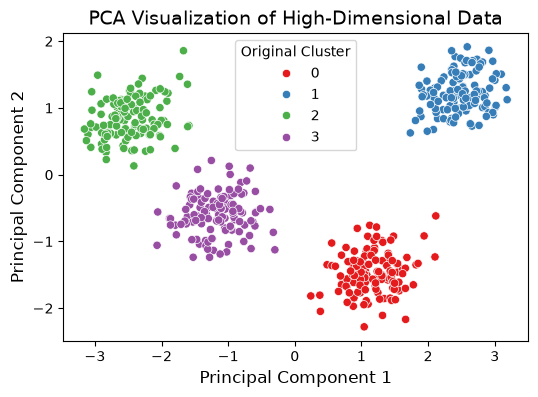

Explained variance ratio: [0.64327878 0.21039738]


In [56]:
# Scatter plot of PCA results
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="PC1", 
    y="PC2", 
    hue="OriginalCluster", 
    data=df_pca, 
    palette="Set1", 
)
# Add labels and title
plt.title("PCA Visualization of High-Dimensional Data", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title="Original Cluster")
plt.show()
# Display explained variance ratio again
print("Explained variance ratio:", pca.explained_variance_ratio_)


Q10. (Mini Project – Complete Pipeline)
Choose a real-world dataset with multiple numerical features (e.g., Iris, Wine, or
any dataset of your choice).
Perform the complete pipeline:
1. Load and select numerical features
2. Scale the data
3. Apply DBSCAN and visualize (if possible in 2D)
4. Apply PCA to reduce to 2 components
5. Visualize the PCA results

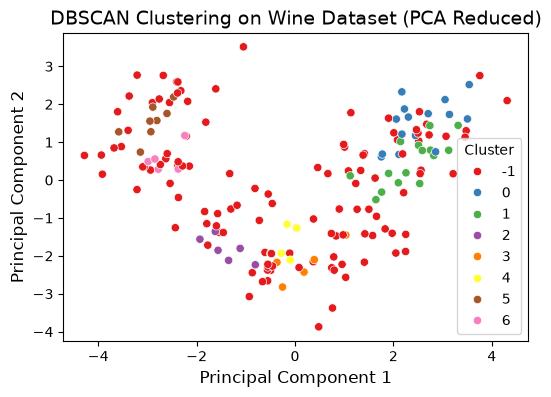

Explained variance ratio: [0.36198848 0.1920749 ]


In [57]:
from sklearn.datasets import load_wine
# Load Wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target   # original wine class labels
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=5)  
db_labels = dbscan.fit_predict(X_scaled)
# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Create DataFrame with PCA results + DBSCAN labels
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["DBSCAN_Cluster"] = db_labels
df_pca["OriginalClass"] = y
# Scatter plot of PCA results
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="DBSCAN_Cluster",
    data=df_pca,palette="Set1",)
plt.title("DBSCAN Clustering on Wine Dataset (PCA Reduced)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title="Cluster")
plt.show()
# Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)